<a href="https://colab.research.google.com/github/Prafullh/hotel-management-ml/blob/main/hotel_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("hotel_bookings.csv")
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.columns


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
df["country"]

,country
0,PRT
1,PRT
2,GBR
3,GBR
4,GBR
...,...
119385,BEL
119386,FRA
119387,DEU
119388,GBR


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df["agent"]=df["agent"].fillna(0).astype(int)
df["children"]=df["children"].fillna(0).astype(int)
df.drop(columns=["company"],inplace =True)
df["country"]=df["country"].replace("nan",None).fillna("Unknown")

droping company column and filling the 0 in agent column


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# Returns the total count of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 32001


In [ ]:
# This shows all rows that are duplicates
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.head())

            hotel  is_canceled  lead_time  arrival_date_year  \
5    Resort Hotel            0         14               2015   
22   Resort Hotel            0         72               2015   
43   Resort Hotel            0         70               2015   
138  Resort Hotel            1          5               2015   
200  Resort Hotel            0          0               2015   

    arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
5                 July                        27                          1   
22                July                        27                          1   
43                July                        27                          2   
138               July                        28                          5   
200               July                        28                          7   

     stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
5                          0                     2       2  ...   
22    

In [ ]:
# Check for rows that are identical across a subset of core features, including lead_time
true_clones = df.duplicated(subset=['lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'agent', 'adr']).sum()
print(f"True system clones (everything identical including lead_time): {true_clones}")

True system clones (everything identical including lead_time): 41667


In [ ]:
# Drop completely identical rows, keeping only the first occurrence
df_cleaned = df.drop_duplicates()
print(f"New dataset shape: {df_cleaned.shape}")

New dataset shape: (87389, 31)


In [ ]:
ghost_bookings = df_cleaned[(df_cleaned['adults'] == 0) & (df_cleaned['children'] == 0) & (df_cleaned['babies'] == 0)]
print(f"Number of bookings with 0 guests: {len(ghost_bookings)}")

Number of bookings with 0 guests: 166


In [ ]:
# Drop the ghost bookings by keeping only rows where total guests > 0
df_cleaned = df_cleaned[(df_cleaned['adults'] > 0) | (df_cleaned['children'] > 0) | (df_cleaned['babies'] > 0)]

In [ ]:
# Create total nights column
df_cleaned['total_stays'] = df_cleaned['stays_in_weekend_nights'] + df_cleaned['stays_in_week_nights']

In [ ]:
# Total humans in the booking
df_cleaned['total_guests'] = df_cleaned['adults'] + df_cleaned['children'] + df_cleaned['babies']

# Is it a family booking
df_cleaned['is_family'] = ((df_cleaned['children'] > 0) | (df_cleaned['babies'] > 0)).astype(int)

In [ ]:

df_cleaned['room_type_mismatch'] = (df_cleaned['reserved_room_type'] != df_cleaned['assigned_room_type']).astype(int)

In [ ]:
print(df_cleaned.groupby('deposit_type')['is_canceled'].mean() * 100)

deposit_type
No Deposit    26.719952
Non Refund    94.701349
Refundable    24.299065
Name: is_canceled, dtype: float64


In [ ]:
# Group lead time into buckets and see cancellation rate
import numpy as np
df_cleaned['lead_time_bucket'] = pd.qcut(df_cleaned['lead_time'], q=5, labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
print(df_cleaned.groupby('lead_time_bucket')['is_canceled'].mean() * 100)

lead_time_bucket
Very Short     8.418045
Short         25.499823
Medium        32.085592
Long          34.309283
Very Long     38.189769
Name: is_canceled, dtype: float64


/tmp/ipykernel_11242/1758505051.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_cleaned.groupby('lead_time_bucket')['is_canceled'].mean() * 100)


In [ ]:

categorical_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'country']


df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

In [ ]:

columns_to_drop = [
    'reservation_status',        .
    'reservation_status_date',
    'arrival_date',
    'arrival_date_month'
]


df_final = df_encoded.drop(columns=columns_to_drop, errors='ignore')

In [ ]:
X=df_final.drop(columns=["is_canceled"])
y = df_final['is_canceled']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 69778 rows
Testing set size: 17445 rows


In [ ]:
# Show all columns that are still text/strings
print(X_train.select_dtypes(include=['object', 'category']).columns)

Index(['reserved_room_type', 'assigned_room_type', 'lead_time_bucket'], dtype='object')


In [ ]:

categorical_cols = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'deposit_type', 'customer_type', 'reserved_room_type', 'assigned_room_type'
]


if 'country_grouped' in df_cleaned.columns:
    categorical_cols.append('country_grouped')

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)


columns_to_drop = ['reservation_status', 'reservation_status_date', 'arrival_date', 'arrival_date_month', 'country']
df_final = df_encoded.drop(columns=columns_to_drop, errors='ignore')


X = df_final.drop(columns=['is_canceled'])
y = df_final['is_canceled']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# 1. Gather all base categorical text columns
categorical_cols = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'deposit_type', 'customer_type', 'reserved_room_type', 'assigned_room_type'
]

# 2. Add our engineered 'lead_time_bucket' column explicitly
if 'lead_time_bucket' in df_cleaned.columns:
    categorical_cols.append('lead_time_bucket')

# 3. Add 'country_grouped' if you created it earlier
if 'country_grouped' in df_cleaned.columns:
    categorical_cols.append('country_grouped')

# 4. Run One-Hot Encoding on everything in that list
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 5. Drop illegal future leakage columns & raw datetimes
columns_to_drop = ['reservation_status', 'reservation_status_date', 'arrival_date', 'arrival_date_month', 'country']
df_final = df_encoded.drop(columns=columns_to_drop, errors='ignore')

# 6. Re-split into X and y
X = df_final.drop(columns=['is_canceled'])
y = df_final['is_canceled']

# 7. Final Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Look for any columns that are NOT integers, floats, or booleans
non_numeric_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

if len(non_numeric_cols) == 0:
    print(" Success! Every single column is 100% numerical. The model cannot crash now!")
else:
    print(f" Wait! These columns are still text/categorical: {non_numeric_cols}")

✨ Success! Every single column is 100% numerical. The model cannot crash now!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)
print("training the model please wait....")
model.fit(X_train,y_train)
print("training complete")



training the model please wait....
training complete


In [ ]:
# Get predictions for both sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy for both
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy: {test_acc:.2f}%")

Training Accuracy: 83.25%
Testing Accuracy: 81.82%


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f"All CV Scores: {cv_scores}")
print(f"Average CV Accuracy: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard Deviation (Variance): {np.std(cv_scores) * 100:.2f}%")

All CV Scores: [0.81721124 0.8174262  0.81305532 0.81963454 0.8169115 ]
Average CV Accuracy: 81.68%
Standard Deviation (Variance): 0.21%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances and pair them with column names
importances = model.feature_importances_
feature_names = X_train.columns

# Create a dataframe for easy sorting
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

print("Top 10 Most Important Features predicting cancellation:")
print(df_importance)

Top 10 Most Important Features predicting cancellation:
                         Feature  Importance
0                      lead_time    0.130082
17     total_of_special_requests    0.100456
21            room_type_mismatch    0.073368
16   required_car_parking_spaces    0.070032
32      market_segment_Online TA    0.060079
13                         agent    0.057243
38       deposit_type_Non Refund    0.045901
15                           adr    0.045608
10        previous_cancellations    0.043558
31  market_segment_Offline TA/TO    0.033620


=== CORPORATE PERFORMANCE REPORT ===
                precision    recall  f1-score   support

Checked In (0)       0.83      0.93      0.88     12643
  Canceled (1)       0.75      0.51      0.61      4802

      accuracy                           0.82     17445
     macro avg       0.79      0.72      0.74     17445
  weighted avg       0.81      0.82      0.81     17445

ROC-AUC Score: 0.8662


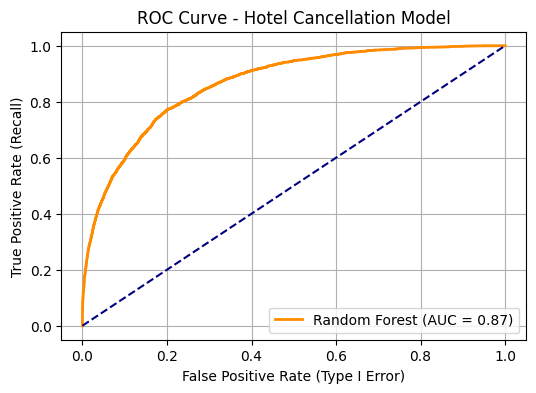

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)



y_pred_proba = model.predict_proba(X_test)[:, 1]


print(" CORPORATE PERFORMANCE REPORT ")
print(classification_report(y_test, y_pred, target_names=['Checked In (0)', 'Canceled (1)']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Hotel Cancellation Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize the LightGBM Model
# learning_rate controls how aggressively each new tree corrects the previous mistakes
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# 2. Train the model
print("Training LightGBM model... Please wait...")
lgb_model.fit(X_train, y_train)
print("Training complete!\n")

# 3. Predict on the test set
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 4. Generate the performance metrics
print("=== LIGHTGBM PERFORMANCE REPORT ===")
print(classification_report(y_test, y_pred_lgb, target_names=['Checked In (0)', 'Canceled (1)']))
print(f"LightGBM ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

Training LightGBM model... Please wait...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19207, number of negative: 50571
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1133
[LightGBM] [Info] Number of data points in the train set: 69778, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275259 -> initscore=-0.968103
[LightGBM] [Info] Start training from score -0.968103
Training complete!

=== LIGHTGBM PERFORMANCE REPORT ===
                precision    recall  f1-score   support

Checked In (0)       0.85      0.93      0.89     12643
  Canceled (1)       0.75      0.56      0.64      4802

      accuracy                           0.83     17445
     macro avg       0.80      0.74   

In [ ]:
# Check train vs test accuracy for LightGBM
train_acc_lgb = lgb_model.score(X_train, y_train) * 100
test_acc_lgb = lgb_model.score(X_test, y_test) * 100

print(f"LightGBM Training Accuracy: {train_acc_lgb:.2f}%")
print(f"LightGBM Testing Accuracy: {test_acc_lgb:.2f}%")

LightGBM Training Accuracy: 83.13%
LightGBM Testing Accuracy: 82.64%
